## SimpleImputer
### This notebook outlines the usage of Simple Imputer (Univariate Imputation).
### Simple Imputer substitutes missing values statistics (mean, median, ...)
#### Dataset: [https://github.com/subashgandyer/datasets/blob/main/heart_disease.csv]

**Demographic**
- Sex: male or female(Nominal)
- Age: Age of the patient;(Continuous - Although the recorded ages have been truncated to whole numbers, the concept of age is continuous)

**Behavioral**
- Current Smoker: whether or not the patient is a current smoker (Nominal)
- Cigs Per Day: the number of cigarettes that the person smoked on average in one day.(can be considered continuous as one can have any number of cigarettes, even half a cigarette.)

**Medical(history)**
- BP Meds: whether or not the patient was on blood pressure medication (Nominal)
- Prevalent Stroke: whether or not the patient had previously had a stroke (Nominal)
- Prevalent Hyp: whether or not the patient was hypertensive (Nominal)
- Diabetes: whether or not the patient had diabetes (Nominal)

**Medical(current)**
- Tot Chol: total cholesterol level (Continuous)
- Sys BP: systolic blood pressure (Continuous)
- Dia BP: diastolic blood pressure (Continuous)
- BMI: Body Mass Index (Continuous)
- Heart Rate: heart rate (Continuous - In medical research, variables such as heart rate though in fact discrete, yet are considered continuous because of large number of possible values.)
- Glucose: glucose level (Continuous)

**Predict variable (desired target)**
- 10 year risk of coronary heart disease CHD (binary: “1”, means “Yes”, “0” means “No”)

In [171]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [172]:
df=pd.read_csv("https://raw.githubusercontent.com/subashgandyer/datasets/main/heart_disease.csv")
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


### How many Categorical variables in the dataset?

In [173]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


### How many Missing values in the dataset?
Hint: df.Series.isna( ).sum( )

In [174]:
for i, col in enumerate(df.columns):
    missing_data = df[col].isna().sum()
    perc = missing_data / len(df) * 100
    print(f'Feature {i+1} >> Missing entries: {missing_data} | Percentage: {round(perc, 2)}')

Feature 1 >> Missing entries: 0 | Percentage: 0.0
Feature 2 >> Missing entries: 0 | Percentage: 0.0
Feature 3 >> Missing entries: 105 | Percentage: 2.48
Feature 4 >> Missing entries: 0 | Percentage: 0.0
Feature 5 >> Missing entries: 29 | Percentage: 0.68
Feature 6 >> Missing entries: 53 | Percentage: 1.25
Feature 7 >> Missing entries: 0 | Percentage: 0.0
Feature 8 >> Missing entries: 0 | Percentage: 0.0
Feature 9 >> Missing entries: 0 | Percentage: 0.0
Feature 10 >> Missing entries: 50 | Percentage: 1.18
Feature 11 >> Missing entries: 0 | Percentage: 0.0
Feature 12 >> Missing entries: 0 | Percentage: 0.0
Feature 13 >> Missing entries: 19 | Percentage: 0.45
Feature 14 >> Missing entries: 1 | Percentage: 0.02
Feature 15 >> Missing entries: 388 | Percentage: 9.16
Feature 16 >> Missing entries: 0 | Percentage: 0.0


### Bonus: Visual representation of missing values

<Axes: >

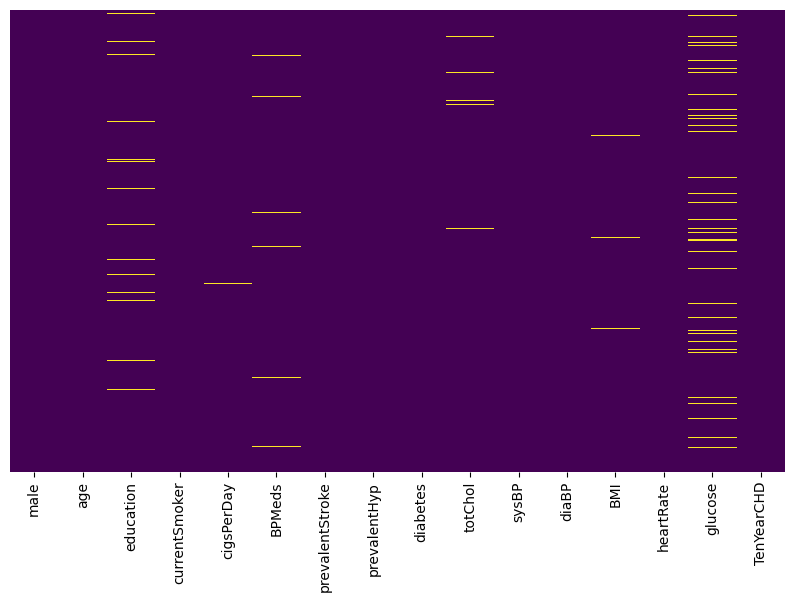

In [175]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isna(), cbar=False, cmap='viridis', yticklabels=False)

### Import SimpleImputer

In [176]:
from sklearn.impute import SimpleImputer

### Create SimpleImputer object with 'mean' strategy

In [177]:
imp = SimpleImputer(missing_values = np.nan, strategy='mean')

### Optional - converting df into numpy array (There is a way to directly impute from dataframe as well)

In [178]:
data = df.values

In [179]:
X = data[:, :-1]
y = data[:, -1]

### Fit the imputer model on dataset to calculate statistic for each column

In [180]:
imp.fit(X)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


### Trained imputer model is applied to dataset to create a copy of dataset with all filled missing values from the calculated statistic using transform( ) 

In [181]:
df_new = pd.DataFrame(imp.transform(X), columns=df.columns[:-1])

### Sanity Check: Whether missing values are filled or not

In [182]:
df_new.isna().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
dtype: int64

### Let's try to visualize the missing values.

<Axes: >

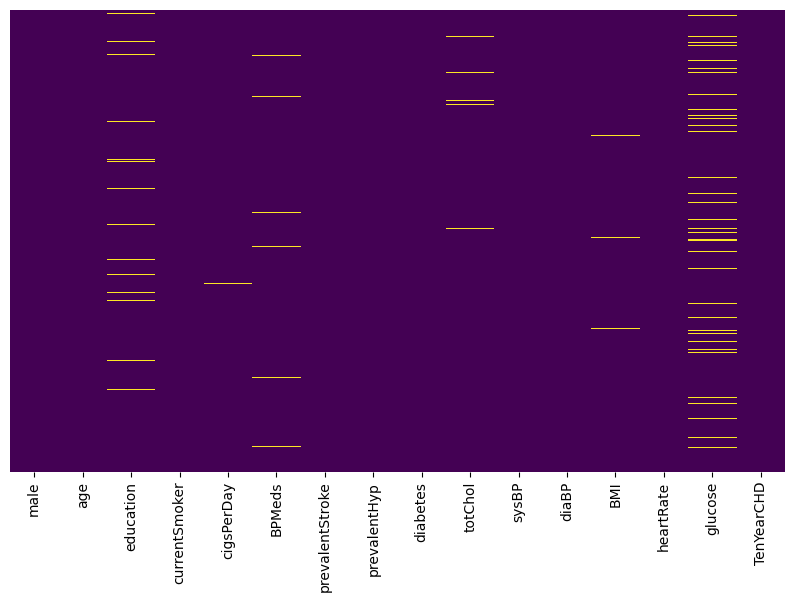

In [183]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isna(), cbar=False, cmap='viridis', yticklabels=False)

<Axes: >

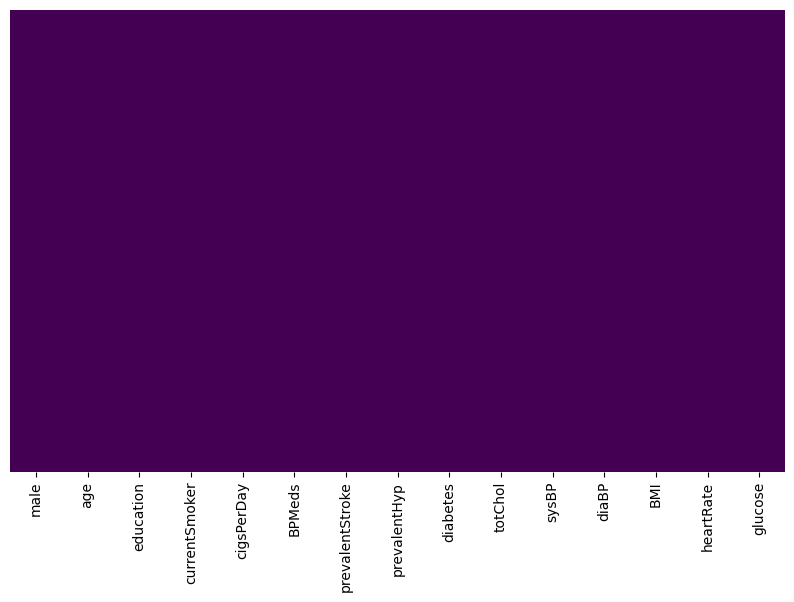

In [184]:
plt.figure(figsize=(10,6))
sns.heatmap(df_new.isna(), cbar=False, cmap='viridis', yticklabels=False)

# Check if these datasets contain missing data
### Load the datasets

In [185]:
X_train = pd.read_csv("X_train.csv")
Y_train = pd.read_csv("Y_train.csv")
Y_test = pd.read_csv("Y_test.csv")
X_test = pd.read_csv("X_test.csv")

In [186]:
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((384, 12), (384, 1), (96, 12), (96, 1))

<Axes: >

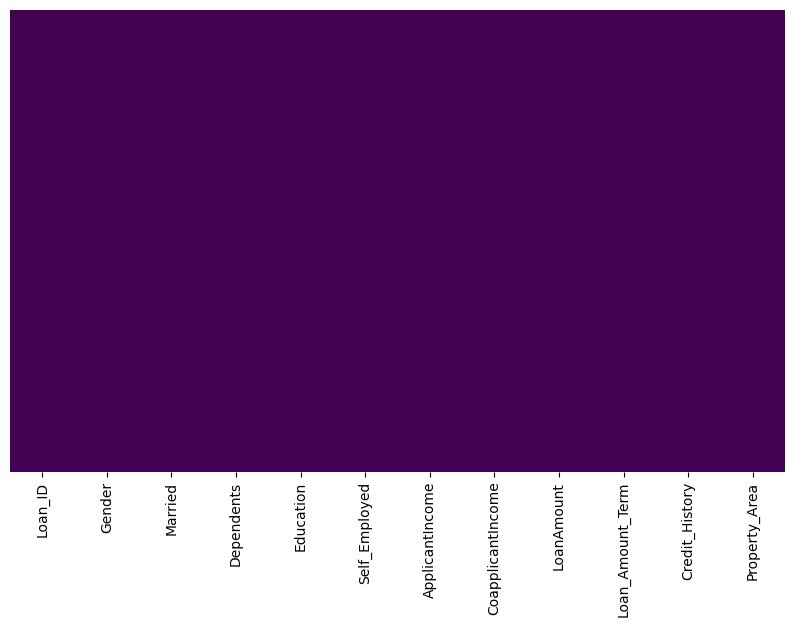

In [187]:
plt.figure(figsize=(10,6))
sns.heatmap(X_train.isna(), cbar=False, cmap='viridis', yticklabels=False)

### Is there missing data in this dataset???

According to heatmap, there is no missing data

# Build a Logistic Regression model Without imputation

In [188]:
X = df[df.columns[:-1]]
y = df[df.columns[-1]]

In [189]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [190]:
model = LogisticRegression()

In [191]:
#model.fit(X,y)

# Drop all rows with missing entries - Build a Logistic Regression model and benchmark the accuracy

In [192]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

In [193]:
df=pd.read_csv("https://raw.githubusercontent.com/subashgandyer/datasets/main/heart_disease.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [194]:
df.shape

(4238, 16)

### Drop rows with missing values

In [195]:
df = df.dropna()
df.shape

(3656, 16)

### Split dataset into X and y

In [196]:
X = df[df.columns[:-1]]
y = df[df.columns[-1]]

In [197]:
print(X.shape, y.shape)

(3656, 15) (3656,)


### Create a pipeline with model parameter

In [198]:
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('model', LogisticRegression())
])

### Create a RepeatedStratifiedKFold with 10 splits and 3 repeats and random_state=1

In [199]:

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

### Call cross_val_score with pipeline, X, y, accuracy metric and cv

In [200]:
scores = cross_val_score(pipeline, X, y, scoring='accuracy', cv=cv)

C:\Users\Sergey\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Sergey\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/m

In [201]:
scores

array([0.85245902, 0.85519126, 0.85245902, 0.8442623 , 0.84699454,
       0.84153005, 0.84657534, 0.85753425, 0.84109589, 0.84109589,
       0.85245902, 0.84972678, 0.85519126, 0.8442623 , 0.85519126,
       0.84153005, 0.84109589, 0.84383562, 0.84931507, 0.84657534,
       0.8579235 , 0.84972678, 0.85245902, 0.8442623 , 0.84972678,
       0.84699454, 0.84931507, 0.85205479, 0.84109589, 0.83561644])

### Print the Mean Accuracy and Standard Deviation from scores

In [202]:
print(f"Mean Accuracy: {round(np.mean(scores), 3)}  | Std: {round(np.std(scores), 3)}")

Mean Accuracy: 0.848  | Std: 0.006


# Build a Logistic Regression model with SimpleImputer Mean Strategy

In [203]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

In [204]:
df=pd.read_csv("https://raw.githubusercontent.com/subashgandyer/datasets/main/heart_disease.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


### Split dataset into X and y

In [205]:
df.shape

(4238, 16)

In [206]:
X = df[df.columns[:-1]]
X.shape

(4238, 15)

In [207]:
y = df[df.columns[-1]]
y

0       0
1       0
2       0
3       1
4       0
       ..
4233    1
4234    0
4235    0
4236    0
4237    0
Name: TenYearCHD, Length: 4238, dtype: int64

### Create a SimpleImputer with mean strategy

In [208]:
imp = SimpleImputer(missing_values = np.nan, strategy='mean')

### Create a Logistic Regression model

In [209]:
model = LogisticRegression()

### Create a pipeline with impute and model parameters

In [210]:
pipeline = Pipeline(steps=[
    ('imputer', imp),
    ('model', model)
])

### Create a RepeatedStratifiedKFold with 10 splits and 3 repeats and random_state=1

In [211]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

### Call cross_val_score with pipeline, X, y, accuracy metric and cv

In [212]:
scores2 = cross_val_score(pipeline, X, y, scoring='accuracy', cv=cv)

C:\Users\Sergey\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Sergey\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/m

In [213]:
scores2

array([0.84669811, 0.85141509, 0.84669811, 0.8490566 , 0.84433962,
       0.84669811, 0.8490566 , 0.84669811, 0.85579196, 0.85106383,
       0.8490566 , 0.85377358, 0.85141509, 0.85613208, 0.84669811,
       0.85141509, 0.84198113, 0.85141509, 0.85815603, 0.8534279 ,
       0.85141509, 0.85141509, 0.8490566 , 0.84433962, 0.85141509,
       0.85613208, 0.85141509, 0.85613208, 0.85106383, 0.8463357 ])

### Print the Mean Accuracy and Standard Deviation

In [214]:
print(f"Mean Accuracy: {round(np.mean(scores2), 3)}  | Std: {round(np.std(scores2), 3)}")

Mean Accuracy: 0.85  | Std: 0.004


### Which accuracy is better? 
- Dropping missing values
- SimpleImputer with Mean Strategy

In [215]:
print("Dropping missing values")
print(f"Mean Accuracy: {round(np.mean(scores), 3)}  | Std: {round(np.std(scores), 3)}")
print("SimpleImputer with Mean Strategy")
print(f"Mean Accuracy: {round(np.mean(scores2), 3)}  | Std: {round(np.std(scores2), 3)}")

Dropping missing values
Mean Accuracy: 0.848  | Std: 0.006
SimpleImputer with Mean Strategy
Mean Accuracy: 0.85  | Std: 0.004


!!!Using SimpleImputer with Mean Strategy has slightly increased the mean Accuracy!!!

# SimpleImputer Mean - Benchmark after Mean imputation with RandomForest

### Import libraries

In [216]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

### Create a SimpleImputer with mean strategy

In [217]:
imp = SimpleImputer(missing_values = np.nan, strategy='mean')

### Create a RandomForest model

In [218]:
model_RF = RandomForestClassifier()

### Create a pipeline

In [219]:
pipeline_RF = Pipeline(steps=[
    ('imputer', imp),
    ('model', model_RF)
])

### Create RepeatedStratifiedKFold

In [220]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

### Create Cross_val_score

In [221]:
scores_RF = cross_val_score(pipeline_RF, X, y, scoring='accuracy', cv=cv)

### Print Mean Accuracy and Standard Deviation

In [222]:
print(f"Mean Accuracy: {round(np.mean(scores_RF), 3)}  | Std: {round(np.std(scores_RF), 3)}")

Mean Accuracy: 0.849  | Std: 0.005


# Assignment
# Run experiments with different Strategies and different algorithms

## STRATEGIES
- Mean
- Median
- Most_frequent
- Constant

## ALGORITHMS
- Logistic Regression
- KNN
- Random Forest
- SVM
- Any other algorithm of your choice

#### Hint: Collect the pipeline creation, KFold, and Cross_Val_Score inside a for loop and iterate over different strategies in a list and different algorithms in a list

In [236]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier

strategies = ['mean', 'median', 'most_frequent', 'constant']

models = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, solver='saga'),
    'KNN':                  KNeighborsClassifier(),
    'Random Forest':        RandomForestClassifier(random_state=1),
    'SVM':                  SVC(),
    'Decision Tree':        DecisionTreeClassifier(random_state=1),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=1),
    'CatBoost':             CatBoostClassifier(random_state=1, verbose=0)
}

results = []

for strategy in strategies:
    for model_name, model in models.items():
        pipeline = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy=strategy)),
            ('scaler',  StandardScaler()),
            ('model',   model)
        ])

        cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
        scores = cross_val_score(pipeline, X, y, scoring='accuracy', cv=cv)

        print(f'Strategy: {strategy} | Model: {model_name} | Accuracy: {round(scores.mean(), 3)} ± {round(scores.std(), 3)}')

        results.append({
            'Strategy': strategy,
            'Model':    model_name,
            'Accuracy': scores.mean(),
            'Std':      scores.std()
        })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
results_df

Strategy: mean | Model: Logistic Regression | Accuracy: 0.855 ± 0.006
Strategy: mean | Model: KNN | Accuracy: 0.834 ± 0.009
Strategy: mean | Model: Random Forest | Accuracy: 0.849 ± 0.006
Strategy: mean | Model: SVM | Accuracy: 0.848 ± 0.004
Strategy: mean | Model: Decision Tree | Accuracy: 0.754 ± 0.02
Strategy: mean | Model: Gradient Boosting | Accuracy: 0.846 ± 0.008
Strategy: mean | Model: CatBoost | Accuracy: 0.846 ± 0.006
Strategy: median | Model: Logistic Regression | Accuracy: 0.855 ± 0.006
Strategy: median | Model: KNN | Accuracy: 0.835 ± 0.009
Strategy: median | Model: Random Forest | Accuracy: 0.849 ± 0.006
Strategy: median | Model: SVM | Accuracy: 0.848 ± 0.004
Strategy: median | Model: Decision Tree | Accuracy: 0.754 ± 0.019
Strategy: median | Model: Gradient Boosting | Accuracy: 0.846 ± 0.009
Strategy: median | Model: CatBoost | Accuracy: 0.845 ± 0.006
Strategy: most_frequent | Model: Logistic Regression | Accuracy: 0.855 ± 0.006
Strategy: most_frequent | Model: KNN | Acc

,Strategy,Model,Accuracy,Std
14,most_frequent,Logistic Regression,0.854729,0.005773
0,mean,Logistic Regression,0.854572,0.005802
7,median,Logistic Regression,0.854572,0.005802
21,constant,Logistic Regression,0.853706,0.005733
9,median,Random Forest,0.849382,0.006042
2,mean,Random Forest,0.849381,0.006028
23,constant,Random Forest,0.848831,0.006577
16,most_frequent,Random Forest,0.848752,0.005985
10,median,SVM,0.848200,0.003707
3,mean,SVM,0.848200,0.003707


# Q1: Which is the best strategy for this dataset using Random Forest algorithm?
- MEAN
- MEDIAN
- MOST_FREQUENT
- CONSTANT

In [237]:
results_df[results_df['Model'] == 'Random Forest'].head(1)['Strategy']

9    median
Name: Strategy, dtype: str

# Q2:  Which is the best algorithm for this dataset using Mean Strategy?
- Logistic Regression
- Random Forest
- KNN
- any other algorithm of your choice (BONUS)

In [238]:
results_df[results_df['Strategy'] == 'mean'].head(1)['Model']

0    Logistic Regression
Name: Model, dtype: str

# Q3: Which is the best combination of algorithm and best Imputation Strategy overall?
- Mean , Median, Most_frequent, Constant
- Logistic Regression, Random Forest, KNN

In [239]:
results_df.head(1)[['Strategy',"Model"]]

,Strategy,Model
14,most_frequent,Logistic Regression
